In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Data loading and understanding**

In [23]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Path to your ZIP file
zip_path = '/content/drive/MyDrive/Datasets/creditcard.csv.zip'

# Extract the CSV from the ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/Datasets/')

# Assuming the CSV inside has the same name
csv_path = '/content/drive/MyDrive/Datasets/creditcard.csv'

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_path)

# Show the first few rows to confirm
print(df.head())



   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

**DAta Analysing**

In [24]:
print(df.isnull().sum())
print(df.info())
print(df.describe())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11  

**Target variable analysis**

Class
0    284315
1       492
Name: count, dtype: int64


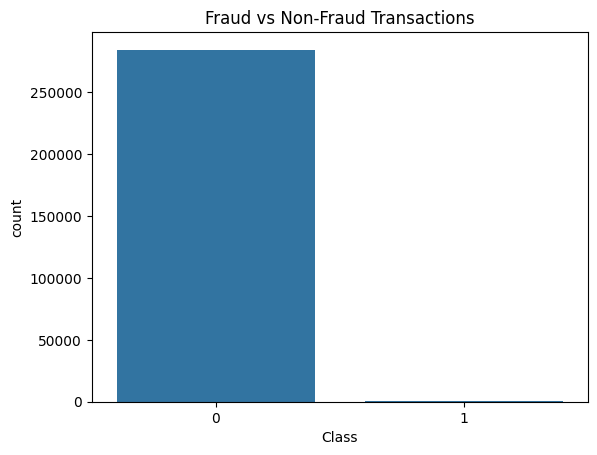

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [25]:
# Count of fraud vs non-fraud
print(df['Class'].value_counts())

# Visualize
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

# Percentage
fraud_ratio = df['Class'].value_counts(normalize=True) * 100
print(fraud_ratio)


**Univariate analysis**

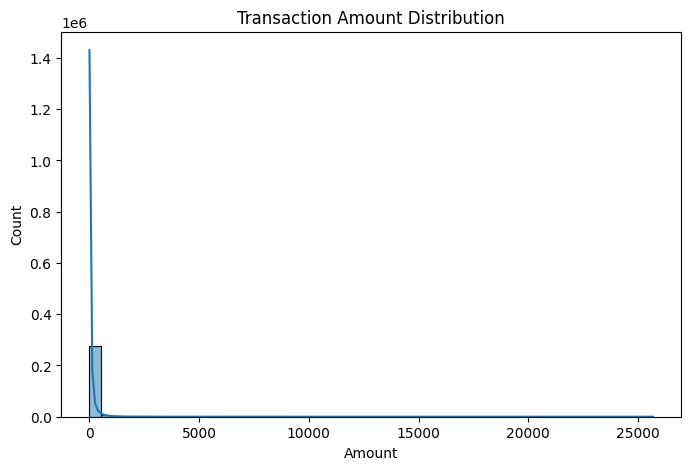

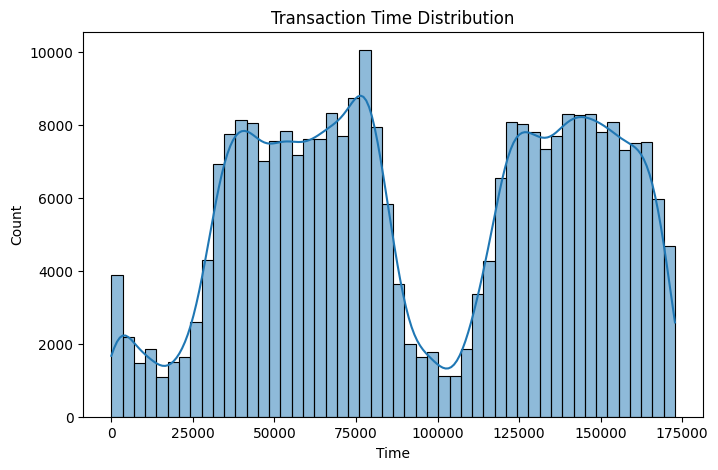

In [26]:
# Distribution of Amount
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()

# Distribution of Time
plt.figure(figsize=(8,5))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title('Transaction Time Distribution')
plt.show()


**Multi analysis**

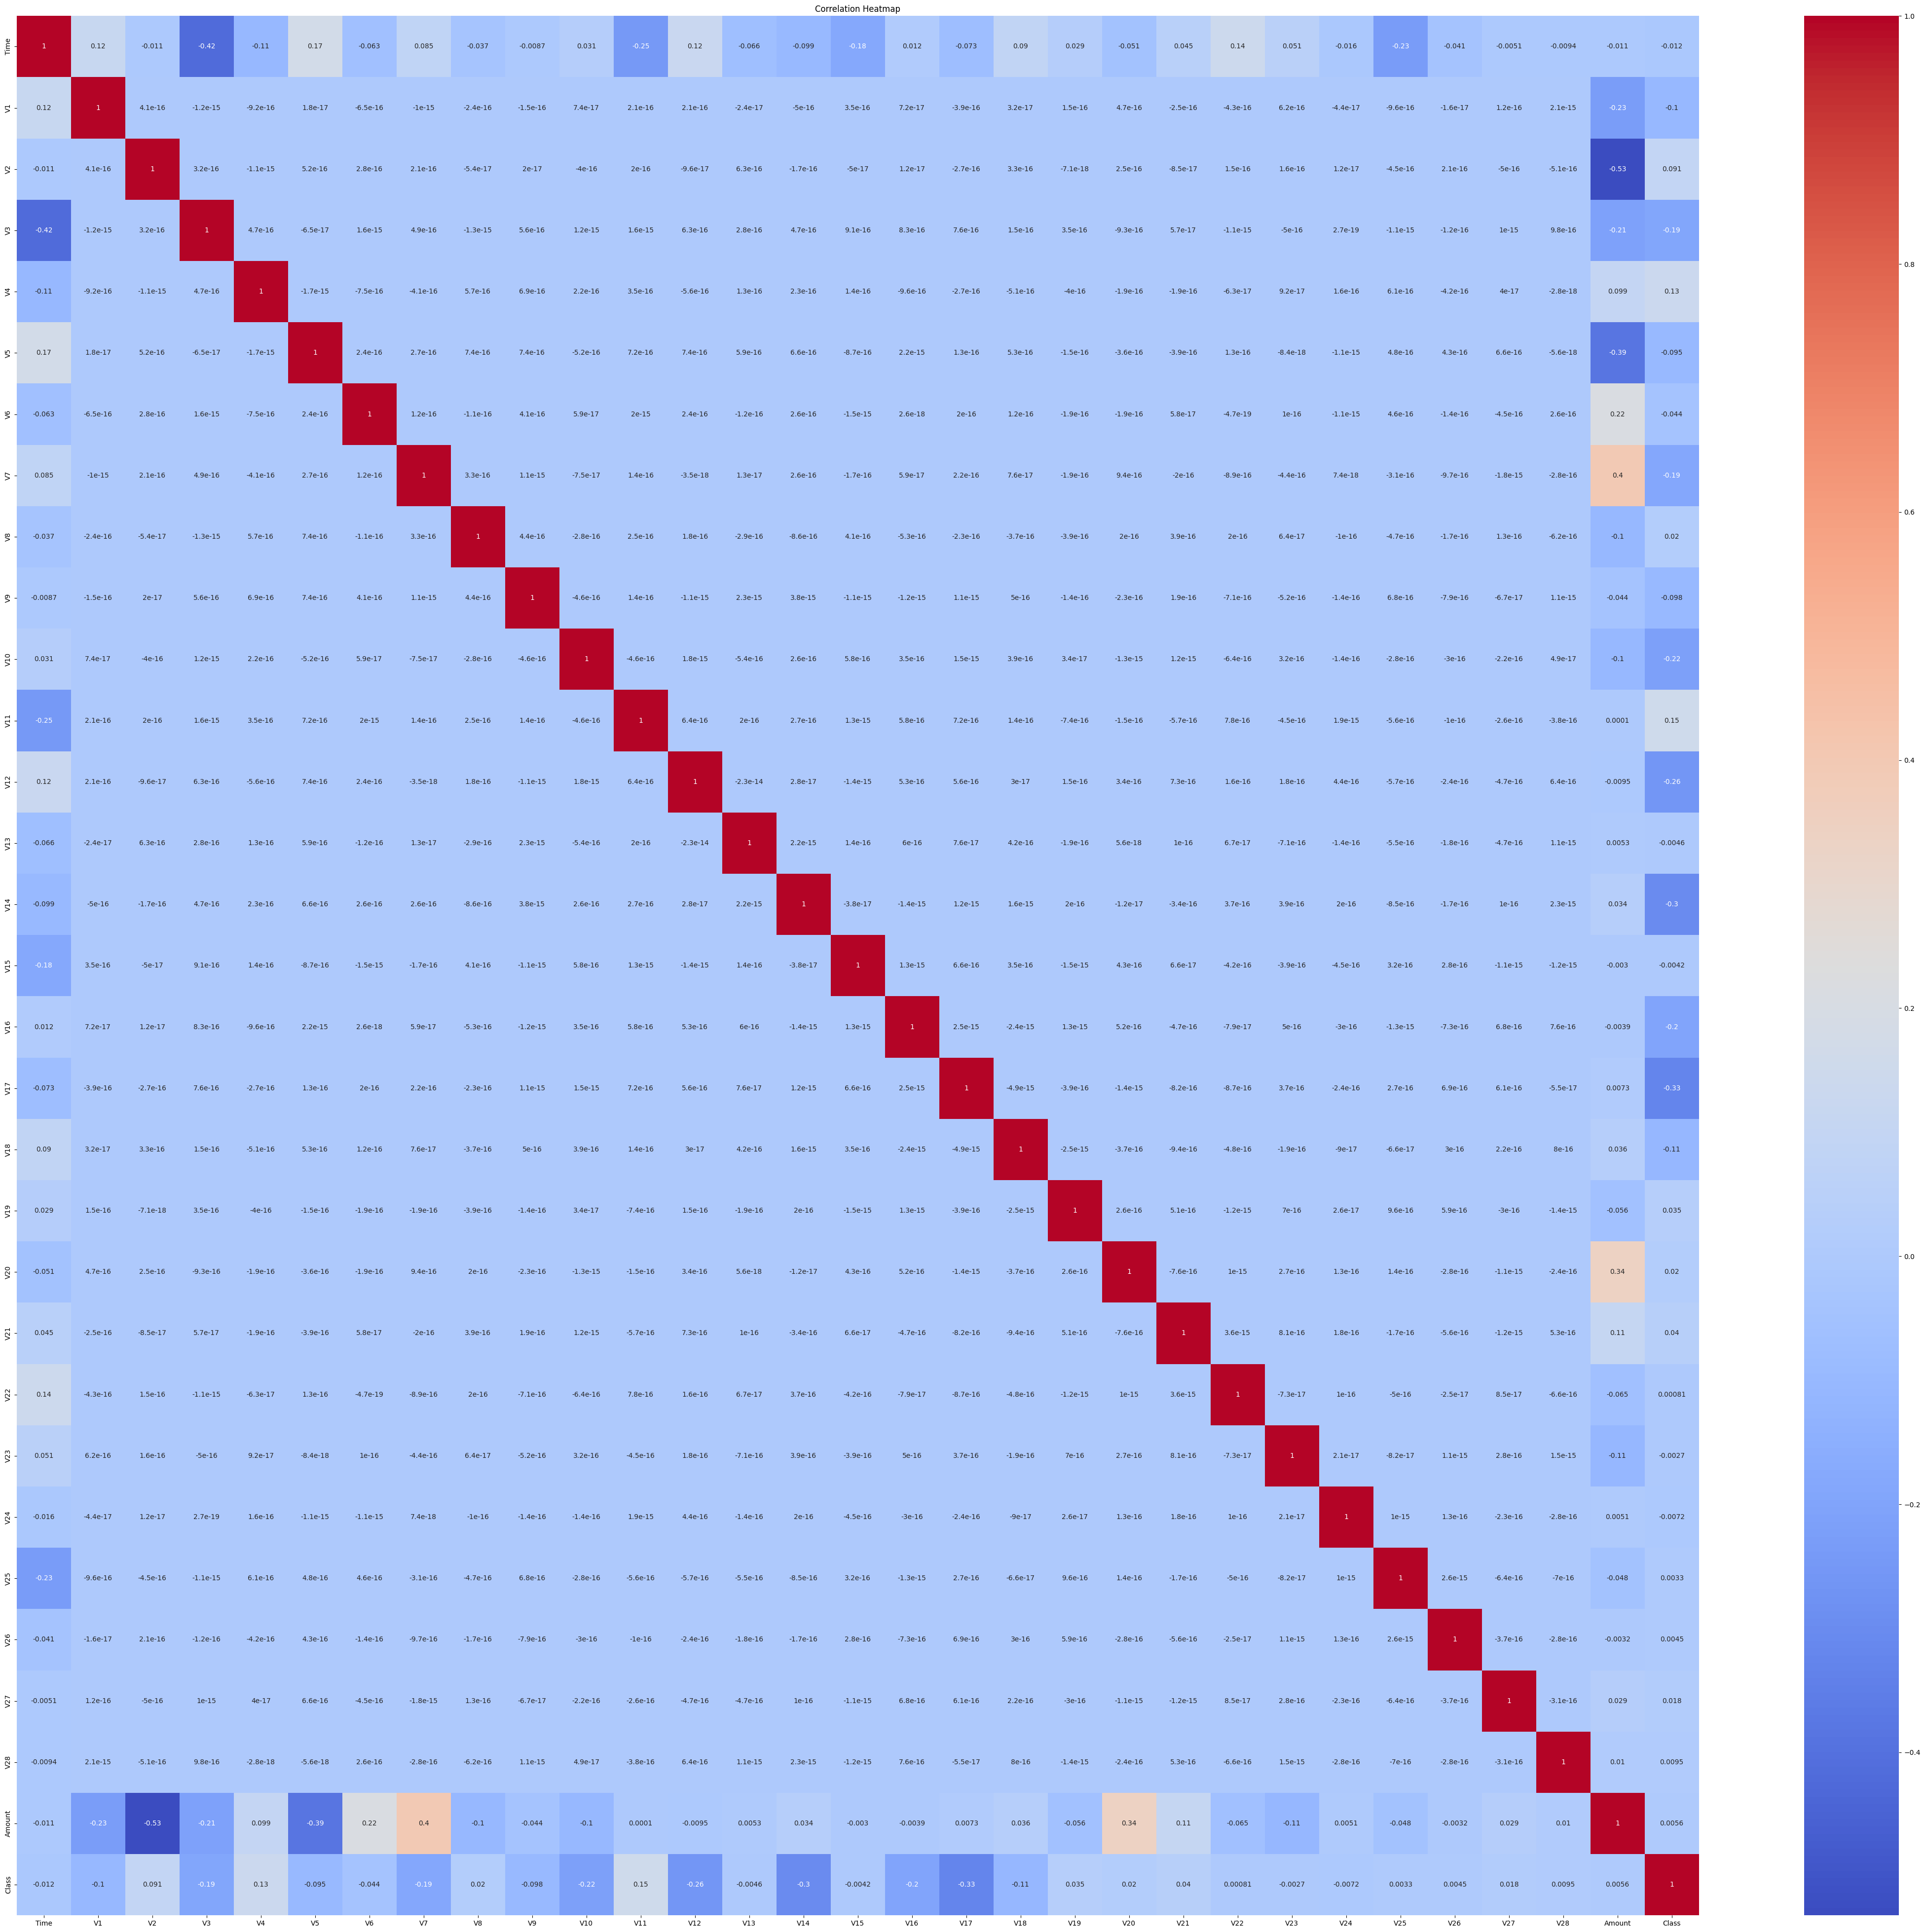

In [27]:
plt.figure(figsize=(55,50))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title('Correlation Heatmap')
plt.show()


**Analysing target**

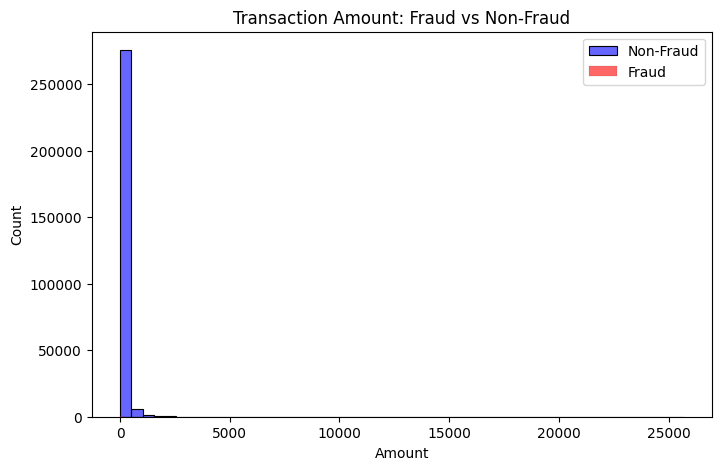

In [28]:
fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]

# Example: Amount
plt.figure(figsize=(8,5))
sns.histplot(non_fraud['Amount'], color='blue', label='Non-Fraud', bins=50, alpha=0.6)
sns.histplot(fraud['Amount'], color='red', label='Fraud', bins=50, alpha=0.6)
plt.title('Transaction Amount: Fraud vs Non-Fraud')
plt.legend()
plt.show()


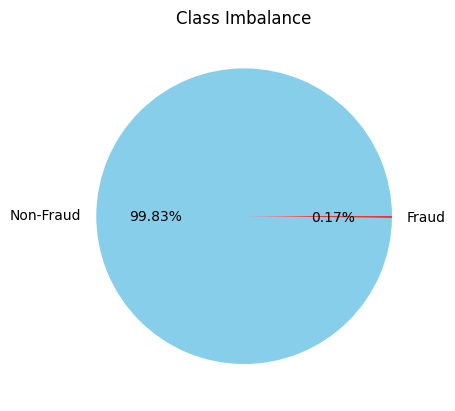

In [29]:
fraud_count = df['Class'].value_counts()
plt.pie(fraud_count, labels=['Non-Fraud','Fraud'], autopct='%1.2f%%', colors=['skyblue','red'])
plt.title('Class Imbalance')
plt.show()


**Outliers Detection**

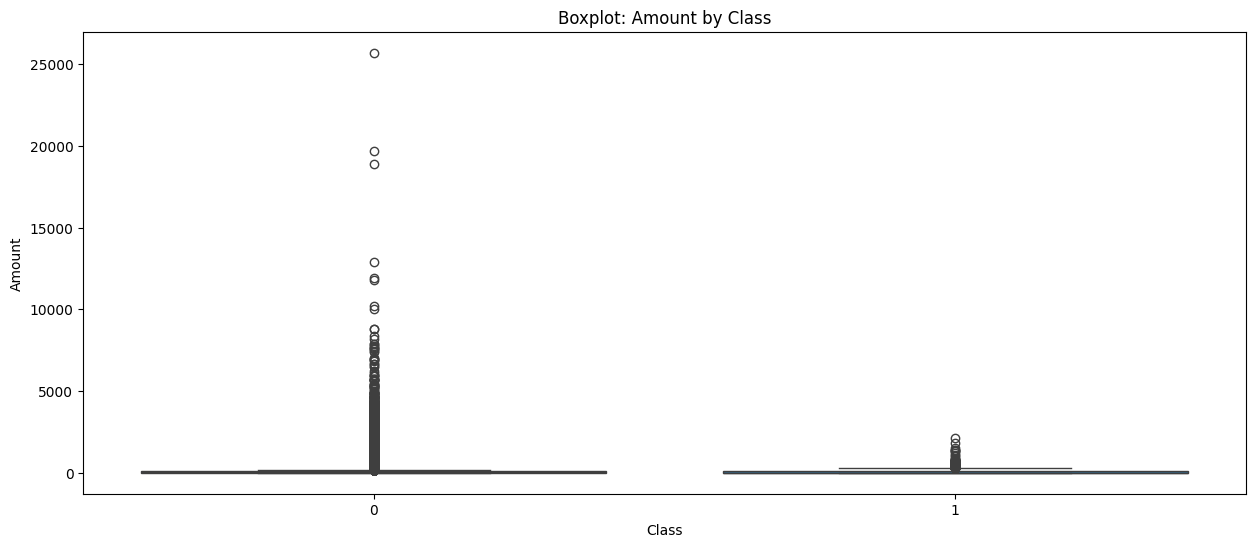

In [30]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Boxplot: Amount by Class')
plt.show()


Number of outliers in Amount: 31904
Lower bound: -101.7475 Upper bound: 184.5125


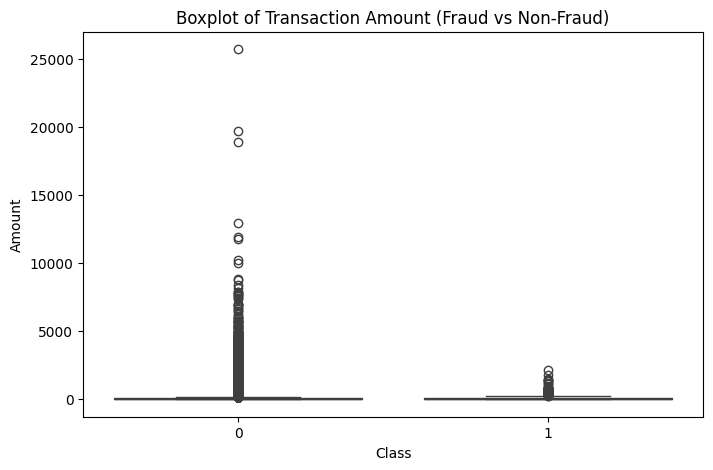

In [31]:
# Calculate Q1, Q3 and IQR for Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers_amount = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]
print("Number of outliers in Amount:", outliers_amount.shape[0])
print("Lower bound:", lower_bound, "Upper bound:", upper_bound)

# Visualize
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Boxplot of Transaction Amount (Fraud vs Non-Fraud)')
plt.show()


In [32]:
numeric_features = df.drop(columns=['Class']).columns  # exclude Class

outlier_counts = {}

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_counts[feature] = len(outliers)

# Convert to DataFrame
outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Num_Outliers'])
outlier_df = outlier_df.sort_values(by='Num_Outliers', ascending=False)
print(outlier_df)


   Feature  Num_Outliers
27     V27         39163
29  Amount         31904
28     V28         30342
20     V20         27770
8       V8         24134
6       V6         22965
23     V23         18541
12     V12         15348
21     V21         14497
14     V14         14149
2       V2         13526
5       V5         12295
4       V4         11148
19     V19         10205
10     V10          9496
7       V7          8948
9       V9          8283
16     V16          8184
18     V18          7533
17     V17          7420
1       V1          7062
26     V26          5596
25     V25          5367
24     V24          4774
13     V13          3368
3       V3          3363
15     V15          2894
22     V22          1317
11     V11           780
0     Time             0


In [33]:
fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]

outlier_summary = {}

for feature in numeric_features:
    Q1 = fraud[feature].quantile(0.25)
    Q3 = fraud[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    out_fraud = fraud[(fraud[feature] < lower) | (fraud[feature] > upper)]

    Q1 = non_fraud[feature].quantile(0.25)
    Q3 = non_fraud[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    out_non_fraud = non_fraud[(non_fraud[feature] < lower) | (non_fraud[feature] > upper)]

    outlier_summary[feature] = {'Fraud': len(out_fraud), 'Non-Fraud': len(out_non_fraud)}

# Convert to DataFrame
outlier_comparison = pd.DataFrame(outlier_summary).T
print(outlier_comparison.sort_values(by='Fraud', ascending=False))


        Fraud  Non-Fraud
V8         98      23974
V27        70      39018
Amount     69      31862
V23        59      18411
V3         53       3095
V1         52       6912
V21        49      14273
V2         46      13327
V28        46      30206
V5         45      12124
V20        41      27649
V25        36       5314
V7         30       8668
V22        24       1289
V10        19       9128
V9         17       8090
V6         15      22829
V11        10        492
V15         8       2883
V12         6      15054
V19         5      10131
V14         4      13800
V24         3       4771
V26         2       5603
Time        0          0
V4          0      10918
V13         0       3365
V18         0       7345
V16         0       7908
V17         0       7038
